In this notebook, we perform inference and forecasting for the LSST Y10 photo-z vs spec-z configurations. We will analyze the performance of photo-z estimates compared to spectroscopic redshifts, and evaluate the implications for cosmological analyses.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table
from astropy.cosmology import FlatLambdaCDM, Flatw0waCDM
from tqdm import tqdm
import warnings

# PDSPL Utils Imports
from pdspl_utils.pairing import (
    get_kdtree_pairs, 
    get_pairs_table_PDSPL, 
    inject_observational_errors, 
    compute_dissimilarity,
    plot_beta_E_vs_D_MC
)

import os
import pickle

from pdspl_utils.inference import draw_lens_from_given_zs, run_dspl_inference
from pdspl_utils.plotting import plot_dspl_corner

warnings.filterwarnings("ignore")

# --- 0. DIRECTORIES & SETUP ---
POSTERIOR_DIRECTORY = '../data/posteriors/forecast_w0waCDM_fixed_scatter'
FIGURE_DIRECTORY = '../figures/forecasts/w0waCDM_fixed_scatter'

%load_ext autoreload
%autoreload 2

# Pairing

In [2]:
## Photo-z vs Spec-z for LSST Y10


# Global configuration
cosmo_true = FlatLambdaCDM(H0=70, Om0=0.3)

########################################################
# 1. Load and preprocess the GGL data table
########################################################
def preprocess_ggl_table(filepath):
    table = Table.read(filepath, format='fits')
    table['color_D_gr'] = table['mag_D_g'] - table['mag_D_r']
    table['color_D_ri'] = table['mag_D_r'] - table['mag_D_i']
    table.rename_column('size_D', 'R_e_arcsec')
    return table

# Update this path if necessary
GGL_table_LSST_Y10 = preprocess_ggl_table("../data/GGL_Catalogs/GGL_20000.0_SQDEG_LSSTY10_SNR_20_seeing_0.5_contrast_02.fits")

########################################################
# 2. Build configuration dictionary with dynamic errors
########################################################
pdspl_samples = {
    "lsst_y10_photo_z": {"table": GGL_table_LSST_Y10, "name": r'LSST Y10 ($z_{D}^{\rm photo}$)', "color": "tab:green"},
    "lsst_y10_spec_z":  {"table": GGL_table_LSST_Y10, "name": r'LSST Y10 ($z_{D}^{\rm spec}$)',  "color": "tab:blue"}
}

base_pairing_keys = ['z_D', 'R_e_arcsec', 'mag_D_i', 'color_D_gr', 'color_D_ri']
base_dissim_keys = ["rel_diff_R_e_arcsec", "rel_diff_z_D", 
                    # "rel_diff_mag_D_i", "rel_diff_color_D_gr", "rel_diff_color_D_ri"
                    "abs_diff_mag_D_i", "abs_diff_color_D_gr", "abs_diff_color_D_ri"
                    ]

# Base errors shared by both setups
base_error_config = {
    'sigma_v_D': 10.0,
    'R_e_arcsec': lambda t: 0.05 * t['R_e_arcsec'],
    'mag_D_i': 1e-3,
    'color_D_gr': 1.4e-3,
    'color_D_ri': 1.4e-3
}

for key, s in pdspl_samples.items():
    s['pairing_keys'] = base_pairing_keys
    s['dissimilarity_keys'] = base_dissim_keys
    s['error_config'] = base_error_config.copy()

# Tailor the redshift errors specifically
pdspl_samples['lsst_y10_photo_z']['error_config']['z_D'] = lambda t: 0.03 * (1 + t['z_D'])
pdspl_samples['lsst_y10_spec_z']['error_config']['z_D'] = 1e-4

########################################################
# 3. Run Error Injection and KD-Tree Pairing
########################################################
N_realizations = 500 # Set lower for a quick test, scale up to 100 for final plots
METRIC = 'rms'
MAX_DISSIMILARITY = 0.1 

# Initialize tracking dictionary
mc_results = {k: {
    'binned_dissim': [], 
    'binned_scatter': [],
    'num_pairs': [],         
    'scatter_in_beta_E': []
} for k in pdspl_samples.keys()}

for i_realization in tqdm(range(N_realizations), desc="MC Realizations"):
    
    for sample_key, s in pdspl_samples.items():
        if len(s["table"]) < 2: continue
            
        # 1. Inject Noise using the new dynamic config
        table_err = inject_observational_errors(s['table'], s['error_config'])
        
        # 2. Find Pairs
        indices, _ = get_kdtree_pairs(table_err, s['pairing_keys'], norm_type='zscore')
        
        # 3. Build PDSPL Tables
        pairs_table = get_pairs_table_PDSPL(s['table'], indices, cosmo_true)
        pairs_table_err = get_pairs_table_PDSPL(table_err, indices, cosmo_true)
        
        # 4. Compute Metric
        pairs_table_err['dissimilarity'] = compute_dissimilarity(
            pairs_table_err, s['dissimilarity_keys'], method=METRIC
        )
        
        # 5. Store State
        s["pairs_analysis"] = {
            "pairs_table": pairs_table,
            "pairs_table_with_errors": pairs_table_err,
            "num_lenses": len(s['table']),
            "num_pairs": len(pairs_table),
            "scatter_in_beta_E": np.std(pairs_table['rel_diff_beta_E']),
            "pair_indices": indices
        }

        mc_results[sample_key]['num_pairs'].append(len(pairs_table))
        mc_results[sample_key]['scatter_in_beta_E'].append(np.std(pairs_table['rel_diff_beta_E']))
        
        # 6. Binning for MC aggregation
        mask = (pairs_table_err['dissimilarity'] < MAX_DISSIMILARITY) & (np.isfinite(pairs_table['rel_diff_beta_E']))
        dissim_masked = pairs_table_err['dissimilarity'][mask]
        delta_beta_masked = pairs_table['rel_diff_beta_E'][mask]
        
        percentiles = np.percentile(dissim_masked, np.arange(0, 101, 10))
        digitized = np.digitize(dissim_masked, percentiles)
        
        run_dissim, run_scatter = [], []
        for i in range(1, len(percentiles)):
            bin_mask = (digitized == i)
            run_dissim.append(np.median(dissim_masked[bin_mask]) if np.any(bin_mask) else np.nan)
            run_scatter.append(np.nanstd(delta_beta_masked[bin_mask]) if np.any(bin_mask) else np.nan)
            
        mc_results[sample_key]['binned_dissim'].append(run_dissim)
        mc_results[sample_key]['binned_scatter'].append(run_scatter)



MC Realizations: 100%|██████████| 500/500 [15:54<00:00,  1.91s/it]


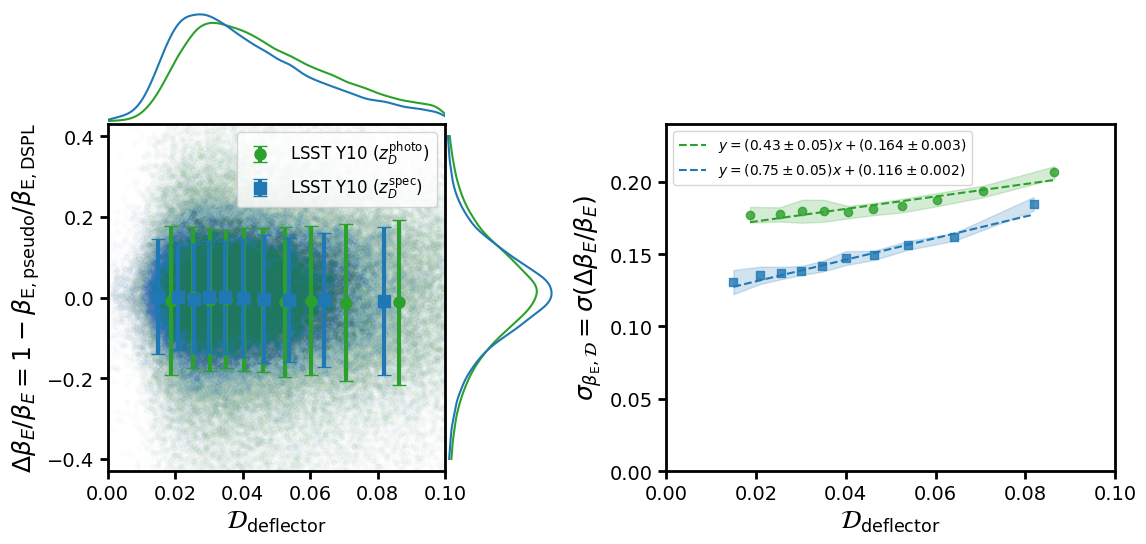

In [3]:
########################################################
# 4. Plot Scatter vs Dissimilarity Comparison
########################################################
# Adjusting the alpha of the scatter plot temporarily inside the plotting function mapping
# if you want clearer visibility, though the default function handles it well.

fig_linear = plot_beta_E_vs_D_MC(
    pdspl_samples, 
    mc_results, 
    fit_type='linear',
    show_fit_eqn_label=True,
    save_path="../figures/beta_E_vs_D_LSST_Y10_photo_vs_spec-z.png"
)

plt.show()

# Inference

In [4]:
# ==============================================================================
# INFERENCE & FORECASTING: LSST Y10 Photo-z vs Spec-z Configurations
# ==============================================================================


truth = {
    'h0': 70.0, 'om': 0.3, 'w0': -1.0, 'wa': 0.0,
    'lambda_int': 1.0, 'lambda_sigma': 0.05,
    'gamma_pl': 2.0, 'gamma_sigma': 0.16
}
fixed_params = {'h0': 70.0}
cosmo_true = Flatw0waCDM(H0=truth['h0'], Om0=truth['om'], w0=truth['w0'], wa=truth['wa'])

# Load the previously saved baseline scenarios to get the purely photo-z Y10 posteriors
with open('../data/samples/forecast_scenarios_w0waCDM_fixed_scatter.pkl', 'rb') as f:
    saved_scenarios = pickle.load(f)
baseline_y10_samples = saved_scenarios['lsst_y10']['samples']

# --- 1. DEFINE THE SCENARIOS ---
specz_data = pdspl_samples['lsst_y10_spec_z']['pairs_analysis']
down_sampling_factor = len(specz_data['pairs_table']) / 2000  

scenarios_to_run = {
    'lsst_y10_zD_spec': {
        'name': r'LSST Y10 ($z_{D}^{\rm spec}$, $z_{S}^{\rm phot}$)',
        'down_sampling': down_sampling_factor, 
        'num_lenses': len(specz_data['pairs_table']), 
        'coeffs': specz_data['scatter_vs_dissimilarity_fit_coeffs'], 
        'pairs_table': specz_data['pairs_table'],                    
        'pairs_table_with_errors': specz_data['pairs_table_with_errors'],
        'redshift_error_rel': [0.0001, 0.03, 0.03], # Spec-z for deflector, photo-z for sources
        'backend_path': os.path.join(POSTERIOR_DIRECTORY, "lsst_y10_zD_spec.h5"),
        'color': 'tab:blue'
    },
    'lsst_y10_all_spec': {
        'name': r'LSST Y10 ($z_{D}^{\rm spec}$, $z_{S}^{\rm spec}$)',
        'down_sampling': down_sampling_factor, 
        'num_lenses': len(specz_data['pairs_table']), 
        'coeffs': specz_data['scatter_vs_dissimilarity_fit_coeffs'], 
        'pairs_table': specz_data['pairs_table'],                    
        'pairs_table_with_errors': specz_data['pairs_table_with_errors'],
        'redshift_error_rel': [0.0001, 0.0001, 0.0001], # Spec-z for everything
        'backend_path': os.path.join(POSTERIOR_DIRECTORY, "lsst_y10_all_spec.h5"),
        'color': "#652e03"  
    }
}

# --- 2. GENERATE MOCK DATASETS ---
print("\n--- Generating Mock Datasets ---")
for key, sc in scenarios_to_run.items():
    num_samples = int(sc['num_lenses'] / sc['down_sampling'])
    kwargs_list = []
    
    print(f"Generating {num_samples} mock systems for: {sc['name']}")
    random_indices = np.random.choice(len(sc['pairs_table']), size=num_samples, replace=False)
    
    for i in random_indices:
        z_lens = sc['pairs_table']["z_D"][i]
        z1 = sc['pairs_table']["z_S1"][i]
        z2 = sc['pairs_table']["z_S2"][i]
        
        dissimilarity = sc['pairs_table_with_errors']['dissimilarity'][i]
        sigma_beta_intrinsic = np.polyval(sc['coeffs'], dissimilarity)
        
        sigma_beta_meas, sigma_beta_los = 0.01, 0.01
        sigma_meas_rel = np.sqrt(sigma_beta_meas**2 + sigma_beta_los**2)
        
        kwargs_list.append(draw_lens_from_given_zs(
            z_lens=z_lens, z1=z1, z2=z2,
            lambda_mst_mean=truth['lambda_int'], lambda_mst_sigma=truth['lambda_sigma'],
            gamma_pl_mean=truth['gamma_pl'], gamma_pl_sigma=truth['gamma_sigma'],
            sigma_beta_intrinsic=sigma_beta_intrinsic,
            sigma_meas_rel=sigma_meas_rel,
            dissimilarity=dissimilarity,
            down_sampling=sc['down_sampling'], 
            with_noise=False, # Asimov inference
            cosmo=cosmo_true, 
            redshift_error_rel=sc['redshift_error_rel']
        ))
    sc['kwargs_list'] = kwargs_list


--- Generating Mock Datasets ---
Generating 2000 mock systems for: LSST Y10 ($z_{D}^{\rm spec}$, $z_{S}^{\rm phot}$)
Generating 2000 mock systems for: LSST Y10 ($z_{D}^{\rm spec}$, $z_{S}^{\rm spec}$)


In [5]:
# --- 3. RUN INFERENCE ---
my_guess = {
    'om': 0.3, 'w0': -1.0, 'wa': 0.0,
    'lambda_int': 1.0, 'lambda_sigma': 0.05,
    'gamma_pl': 2.0, 'gamma_sigma': 0.16
}

my_spreads = {
    'om': 0.1, 'w0': 0.1, 'wa': 0.1,
    'lambda_int': 0.1, 'lambda_sigma': 0.01,
    'gamma_pl': 0.1, 'gamma_sigma': 0.01
}

my_priors = {
    'h0': ('uniform', 50.0, 90.0), 'om': ('uniform', 0.0, 1.0),
    'w0': ('uniform', -3.0, 0.0), 'wa': ('uniform', -5.0, 5.0),
    'lambda_int': ('uniform', 0.8, 1.2), 'lambda_sigma': ('uniform', 0.0, 0.2),
    'gamma_pl': ('uniform', 1.0, 3.0), 'gamma_sigma': ('uniform', 0.0, 0.5)
}

print("\n--- Starting MCMC Inference ---")
for key, sc in scenarios_to_run.items():
    print(f"\nRunning MCMC for: {sc['name']}")
    
    # Isolate scatter coefficients
    coeffs = sc.get('coeffs', [0.0])
    c0, c1, c2 = 0.0, 0.0, 0.0
    if len(coeffs) == 1: c0 = coeffs[0]
    elif len(coeffs) == 2: c1, c0 = coeffs
    elif len(coeffs) >= 3: c2, c1, c0 = coeffs[-3:]
    
    fixed_params_sc = fixed_params.copy()
    fixed_params_sc['beta_c0'] = c0
    fixed_params_sc['beta_c1'] = c1
    fixed_params_sc['beta_c2'] = c2
    
    samples, labels = run_dspl_inference(
        sc['kwargs_list'],
        n_walkers=64, n_steps=2000, n_burn=500,
        initial_guess=my_guess, fixed_params=fixed_params_sc,
        initial_scatter=my_spreads, priors=my_priors,
        backend_path=sc['backend_path']
    )
    sc['samples'] = samples

print("\n--- Inference Complete ---")


--- Starting MCMC Inference ---

Running MCMC for: LSST Y10 ($z_{D}^{\rm spec}$, $z_{S}^{\rm phot}$)
--- Starting DSPL Inference ---
Fixed Params  : ['h0', 'beta_c0', 'beta_c1', 'beta_c2']
Sampled Params: ['om', 'w0', 'wa', 'lambda_int', 'lambda_sigma', 'gamma_pl', 'gamma_sigma']


100%|██████████| 2000/2000 [10:21<00:00,  3.22it/s]



Running MCMC for: LSST Y10 ($z_{D}^{\rm spec}$, $z_{S}^{\rm spec}$)
--- Starting DSPL Inference ---
Fixed Params  : ['h0', 'beta_c0', 'beta_c1', 'beta_c2']
Sampled Params: ['om', 'w0', 'wa', 'lambda_int', 'lambda_sigma', 'gamma_pl', 'gamma_sigma']


100%|██████████| 2000/2000 [10:31<00:00,  3.17it/s]


--- Inference Complete ---



Generating final comparison corner plot...


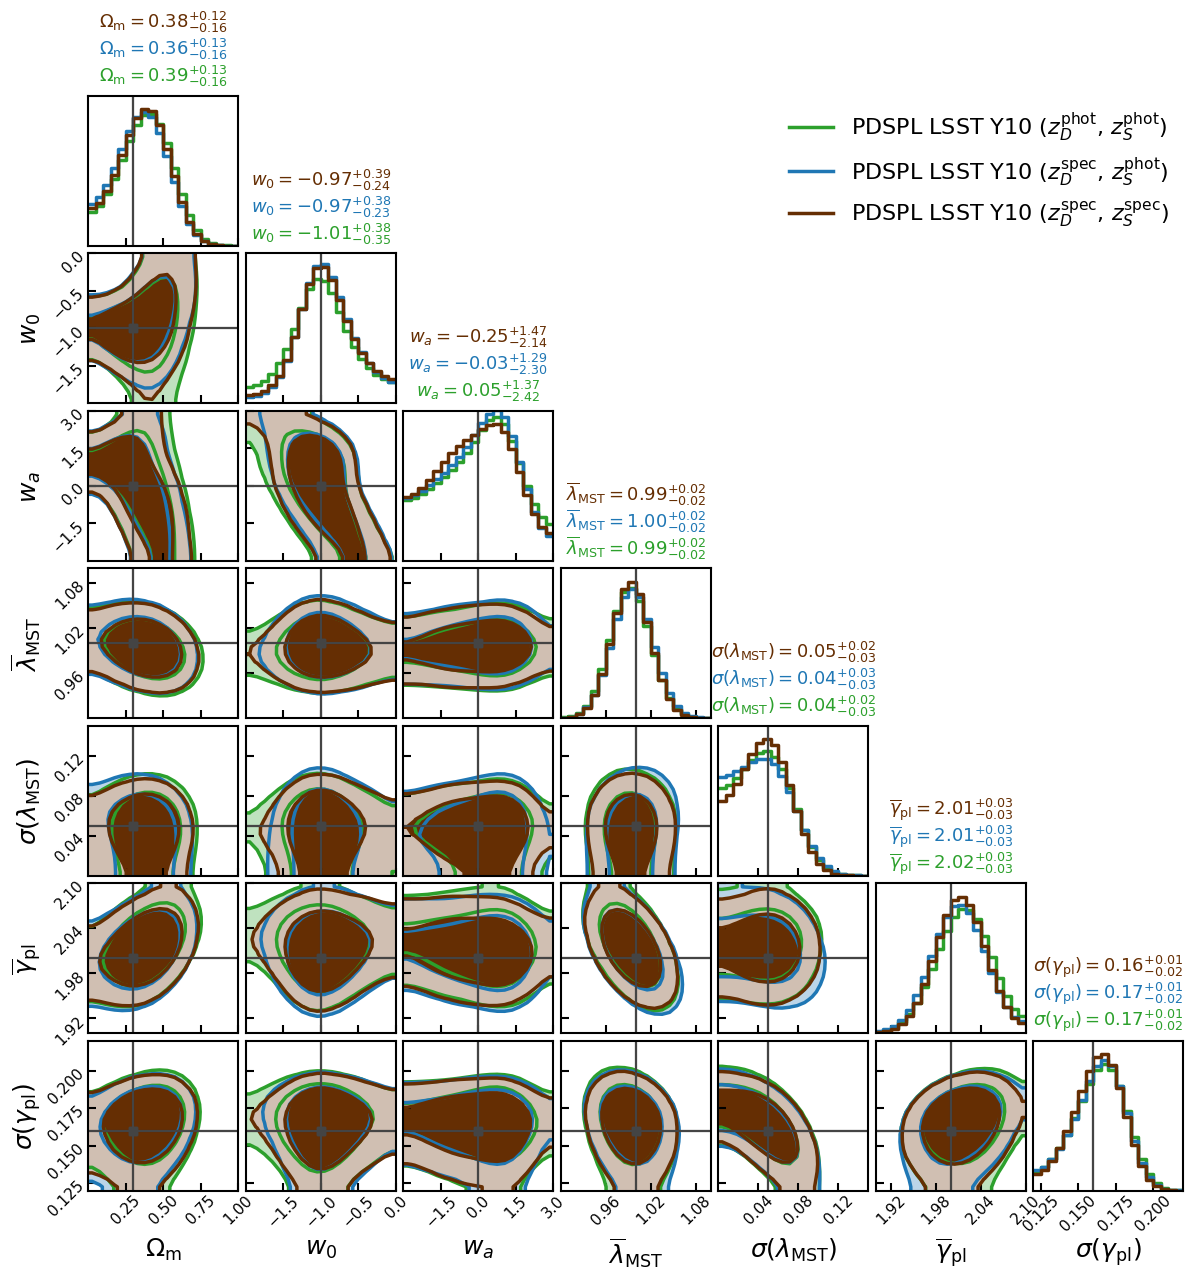


Constraints for PDSPL LSST Y10 ($z_{D}^{\rm phot}$, $z_{S}^{\rm phot}$):
  $\Omega_m$: 0.387 (+0.134 / -0.161)
  $w_0$: -1.010 (+0.379 / -0.353)
  $w_a$: 0.051 (+1.367 / -2.417)
  $\bar{\lambda}_{\rm int}$: 0.992 (+0.018 / -0.017)
  $\sigma({\lambda}_{\rm int})$: 0.045 (+0.024 / -0.027)
  $\bar{\gamma}_{\rm pl}$: 2.018 (+0.029 / -0.032)
  $\sigma({\gamma}_{\rm pl})$: 0.165 (+0.012 / -0.019)

Constraints for PDSPL LSST Y10 ($z_{D}^{\rm spec}$, $z_{S}^{\rm phot}$):
  $\Omega_m$: 0.362 (+0.131 / -0.157)
  $w_0$: -0.969 (+0.377 / -0.232)
  $w_a$: -0.032 (+1.294 / -2.297)
  $\bar{\lambda}_{\rm int}$: 0.995 (+0.018 / -0.018)
  $\sigma({\lambda}_{\rm int})$: 0.043 (+0.026 / -0.028)
  $\bar{\gamma}_{\rm pl}$: 2.011 (+0.029 / -0.029)
  $\sigma({\gamma}_{\rm pl})$: 0.165 (+0.011 / -0.019)

Constraints for PDSPL LSST Y10 ($z_{D}^{\rm spec}$, $z_{S}^{\rm spec}$):
  $\Omega_m$: 0.376 (+0.124 / -0.159)
  $w_0$: -0.970 (+0.386 / -0.240)
  $w_a$: -0.255 (+1.474 / -2.144)
  $\bar{\lambda}_{\rm int}$: 

In [6]:
# --- 4. PREPARE PLOTTING DICTIONARY ---
# Combine the newly run scenarios with the baseline loaded from disk
scenarios_to_plot = {
    'lsst_y10_baseline': {
        'name': r'PDSPL LSST Y10 ($z_{D}^{\rm phot}$, $z_{S}^{\rm phot}$)',
        'samples': baseline_y10_samples,
        'color': 'tab:green'
    },
    'lsst_y10_zD_spec': {
        'name': r'PDSPL LSST Y10 ($z_{D}^{\rm spec}$, $z_{S}^{\rm phot}$)',
        'samples': scenarios_to_run['lsst_y10_zD_spec']['samples'],
        'color': scenarios_to_run['lsst_y10_zD_spec']['color']
    },
    'lsst_y10_all_spec': {
        'name': r'PDSPL LSST Y10 ($z_{D}^{\rm spec}$, $z_{S}^{\rm spec}$)',
        'samples': scenarios_to_run['lsst_y10_all_spec']['samples'],
        'color': scenarios_to_run['lsst_y10_all_spec']['color']
    }
}

latex_labels = {
    'om': r"$\Omega_{\rm m}$", 'w0': r"$w_0$", 'wa': r"$w_a$", 
    'lambda_int': r"$\overline{\lambda}_{\rm MST}$", 
    'gamma_pl': r"$\overline{\gamma}_{\rm pl}$", 
    'gamma_sigma': r"$\sigma({\gamma}_{\rm pl})$", 
    'lambda_sigma': r"$\sigma({\lambda}_{\rm MST})$"
}

custom_ranges = [
    (0, 1),             # om
    (-2, 0),            # w0
    (-3, 3),            # wa
    (truth['lambda_int'] - 0.1, truth['lambda_int'] + 0.1), # lambda_int
    (0.0, 0.15),        # lambda_sigma
    (truth['gamma_pl'] - 0.1, truth['gamma_pl'] + 0.1),     # gamma_pl
    (0.12, 0.22),       # gamma_sigma
]

# --- 5. GENERATE AND SAVE CORNER PLOT ---
print("\nGenerating final comparison corner plot...")
plot_keys = ['lsst_y10_baseline', 'lsst_y10_zD_spec', 'lsst_y10_all_spec']

# Extract specific colors for the plot function if required by your utility
custom_colors_dict = {k: scenarios_to_plot[k]['color'] for k in plot_keys}

fig = plot_dspl_corner(
    scenarios=scenarios_to_plot, 
    truth=truth, 
    fixed_params=fixed_params, 
    scenarios_to_plot=plot_keys, 
    custom_ranges=custom_ranges, 
    latex_labels=latex_labels, 
    figsize=(12, 12),
    show_multiple_titles=True,
    custom_colors_dict=custom_colors_dict,
    save_path=os.path.join(FIGURE_DIRECTORY, "lsst_y10_photoz_vs_specz_forecast.pdf")
)

plt.show()

# Optional: Print summary of constraints for the new runs
for key in plot_keys:
    print(f"\nConstraints for {scenarios_to_plot[key]['name']}:")
    for i, label in enumerate(labels):
        q16, q50, q84 = np.percentile(scenarios_to_plot[key]['samples'][:, i], [16, 50, 84])
        print(f"  {label}: {q50:.3f} (+{q84-q50:.3f} / -{q50-q16:.3f})")

In [7]:
pdspl_samples['lsst_y10_photo_z']['pairs_analysis']

{'pairs_table': <Table length=85925>
 index_1 index_2   lens_id_1   ...  rel_diff_color_D_ri    abs_diff_color_D_ri 
  int64   int64     bytes13    ...        float64                float64       
 ------- ------- ------------- ... ---------------------- ---------------------
    6334       0  lens_5_25850 ...  -0.021237067847552922   0.01666462557916759
   90890       1  lens_78_3793 ...   -0.01030110102583445   0.01121393341658461
       2   70507    lens_0_105 ...   -0.03511464857880234  0.032043349063158644
   80090       3 lens_68_37949 ...   -0.00845488429961322  0.007974388526626797
       4  112387    lens_0_260 ...  -0.017917224709358342  0.021894469240550052
    2404       5   lens_2_5091 ...   0.007785481205710515 0.0068154491822411956
       6   13176    lens_0_305 ...   -0.02993487411375809   0.02675427692044252
       7   77971    lens_0_320 ...   0.011090503347225585   0.00985661018567896
   39551       8   lens_34_462 ...   -0.00938930921400233    0.0098292642399187
   

In [8]:
# Save the MC pairing results for the photo-z vs spec-z experiment
with open("../data/samples/mc_results_photo_vs_specz.pkl", "wb") as f:
    pickle.dump(mc_results, f)

# Save the final forecast scenarios dict for the photo-z vs spec-z experiment
with open("../data/samples/forecast_scenarios_photo_vs_specz.pkl", "wb") as f:
    pickle.dump(scenarios_to_plot, f)